# Initial Exploratory Analysis of Synthetic Data

## Load Data and Data Preparation

In [1]:
import pandas as pd
import numpy as np
import re
import ast
from nltk.corpus import stopwords
import nltk

### 1. Load data
survey_df = pd.read_excel("synthetic_data_mixed_labels.xlsx")

### 2. Data Preparation
# a. Student response preprocessing
stop_words = set(stopwords.words('english'))

def text_preprocessing(text, remove_stopwords=False):
    # Remove regex (any non-alphanumeric characters) and keeping only letters, numbers, and spaces using regex
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    # Lowercasing
    text = text.lower()

    # Remove stopwords
    if remove_stopwords:
        words = [word for word in text.split() if word not in stop_words]
        text = " ".join(words)

    return text

survey_df['student_response'] = survey_df['student_response'].apply(lambda x: text_preprocessing(x))
survey_df['student_response_clean'] = survey_df['student_response'].apply(lambda x: text_preprocessing(x, remove_stopwords=True))

# b. Sort and clean the label
survey_df['all_labels'] = survey_df['all_labels'].apply(lambda x: sorted(x) if isinstance(x, list) else x)

def clean_and_sort_labels(x):
    # Convert string labels to list
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                x_list = ast.literal_eval(x)
            except:
                x_list = x.strip("[]").split(",")
        else:
            x_list = x.split(",")
    elif isinstance(x, list):
        x_list = x
    else:
        return []

    # Clean, deduplicate, and sort
    cleaned = {str(item).strip().strip("[]\"'") for item in x_list if str(item).strip().strip("[]\"'")}
    return sorted(cleaned, key=str.lower)

survey_df['all_labels'] = survey_df['all_labels'].apply(clean_and_sort_labels)

survey_df.head(5)

,course_name,question,student_response,inappropriate_appropriate,category,category_mixed,all_labels,student_response_clean
0,Introduction to Computer Science,Which aspects of this course need improvement?,the lecture recordings are often unclear and t...,appropriate,teaching & delivery,teaching & delivery,[teaching & delivery],lecture recordings often unclear audio quality...
1,Mathematical Methods,Which aspects of this course need improvement?,this course sucks and prof smith is the worst ...,inappropriate,teaching & delivery,mixed,"[course materials & structure, teaching & deli...",course sucks prof smith worst teacher ever com...
2,Physics for Engineers,Which aspects of this course need improvement?,the assignment instructions are very ambiguous...,appropriate,assignment & quiz,mixed,"[assignment & quiz, course materials & structure]",assignment instructions ambiguous due dates cl...
3,General Chemistry,Which aspects of this course need improvement?,the lab manual is outdated and some experiment...,appropriate,course materials & structure,course materials & structure,[course materials & structure],lab manual outdated experiments dont work desc...
4,Introduction to Biology,Which aspects of this course need improvement?,good course overall,appropriate,teaching & delivery,course materials & structure,[course materials & structure],good course overall


## Exploring Label Proportion

### Visualising the Distribution of Appropriate vs Inappropriate Responses

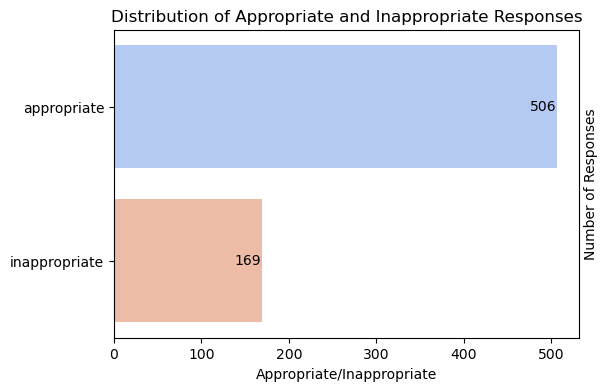

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=survey_df, 
    y="inappropriate_appropriate", 
    hue="inappropriate_appropriate", 
    palette="coolwarm"
)

plt.xlabel("Appropriate/Inappropriate")
plt.ylabel("Number of Responses")
plt.title("Distribution of Appropriate and Inappropriate Responses")
ax.yaxis.set_label_position("right")  # corrected

# Add labels inside bars
for p in ax.patches:
    width = p.get_width()
    ax.text(
        x=width - 0.5,
        y=p.get_y() + p.get_height()/2,
        s=int(width),
        va='center',
        ha='right',
        fontsize=10,
    )

plt.show()


### Visualising the Distribution of the Different Categories

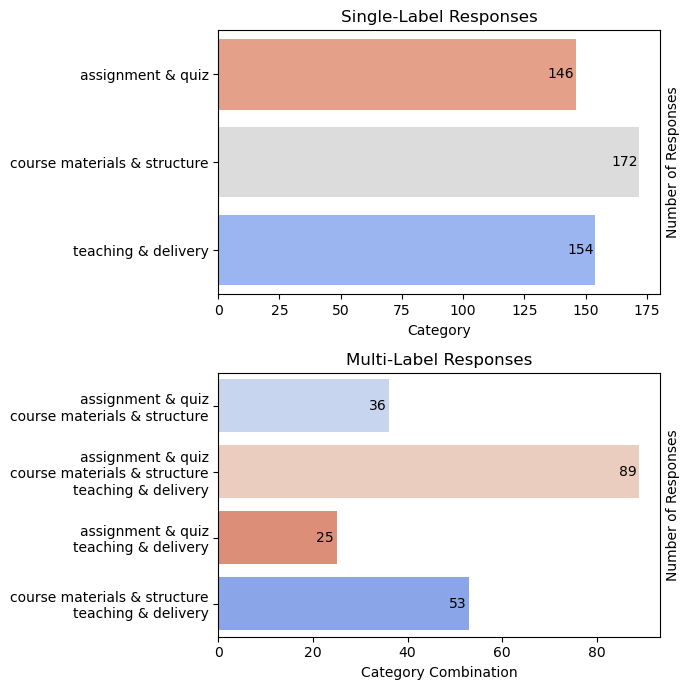

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

survey_df['category_combination'] = survey_df['all_labels'].apply(lambda x: ', '.join(sorted(x)))

### Single-label responses
single_label_df = survey_df[survey_df['all_labels'].apply(len) == 1]
single_label_sorted_categories = sorted(single_label_df['category_combination'].unique())

### Multi-label responses (more than one label)
multi_label_df = survey_df[survey_df['all_labels'].apply(len) > 1].copy() 
multi_label_sorted_categories = sorted(multi_label_df['category_combination'].unique())
multi_label_df.loc[:, 'num_labels'] = multi_label_df['all_labels'].apply(len)

fig, axes = plt.subplots(2, 1, figsize=(7, 7))

# Plot single-label
ax1 = sns.countplot(
    data=single_label_df, 
    y="category_combination", 
    hue="category_combination", 
    dodge=False, 
    palette="coolwarm", 
    order=single_label_sorted_categories,
    legend=False,
    ax=axes[0]
)
ax1.set_xlabel("Category")
ax1.set_ylabel("Number of Responses")
ax1.set_title("Single-Label Responses")
ax1.yaxis.set_label_position("right")


# Add labels on bars
for p in ax1.patches:
    width = p.get_width()
    ax1.text(x=width - 0.5, y=p.get_y() + p.get_height()/2, s=int(width), va='center', ha='right', fontsize=10)

# Plot multi-label
ax2 = sns.countplot(
    data=multi_label_df, 
    y="category_combination", 
    hue="category_combination", 
    dodge=False, 
    palette="coolwarm", 
    order=multi_label_sorted_categories,
    legend=False,
    ax=axes[1]
)
ax2.set_xlabel("Category Combination")
ax2.set_ylabel("Number of Responses")
ax2.set_title("Multi-Label Responses")
new_labels = [label.get_text().replace(", ", "\n") for label in ax2.get_yticklabels()]
ax2.set_yticks(range(len(new_labels)))
ax2.set_yticklabels(new_labels, fontsize=10)

# ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

# Add labels on bars
for p in ax2.patches:
    width = p.get_width()
    ax2.text(x=width - 0.5, y=p.get_y() + p.get_height()/2, s=int(width), va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()


## Visualising Most Common Words in Responses

### Overall Most Common Words

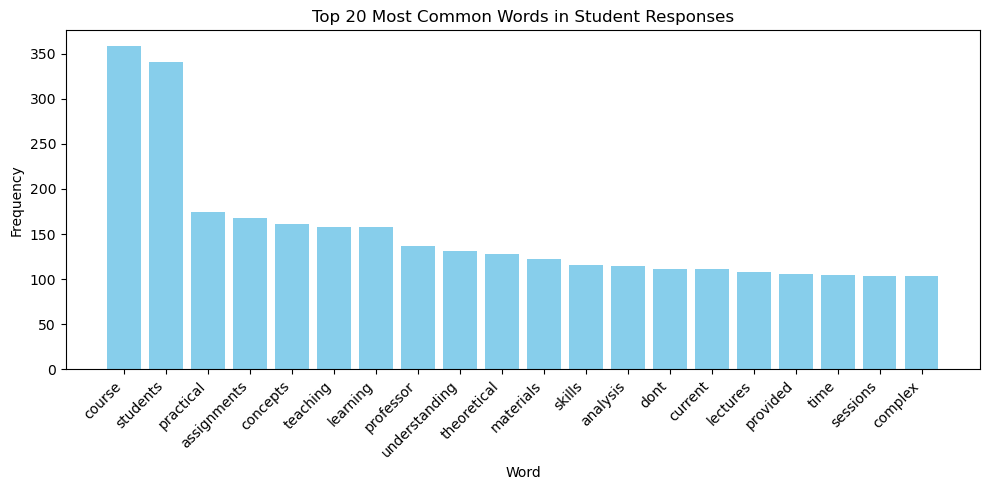

In [4]:
from collections import Counter
import re

# Concatenate everything into one big string
text = " ".join(survey_df["student_response_clean"])

# Split the big string into a list of individual words
words = re.findall(r'\b\w+\b', text)

word_counts = Counter(words)

top_20_words = word_counts.most_common(20)

words, counts = zip(*top_20_words)

plt.figure(figsize=(10,5))
plt.bar(words, counts, color ="skyblue")
plt.xticks(rotation=45, ha="right")

plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Most Common Words in Student Responses")

plt.tight_layout()
plt.show()

### Most Common Words: Appropriate vs Inappropriate Responses

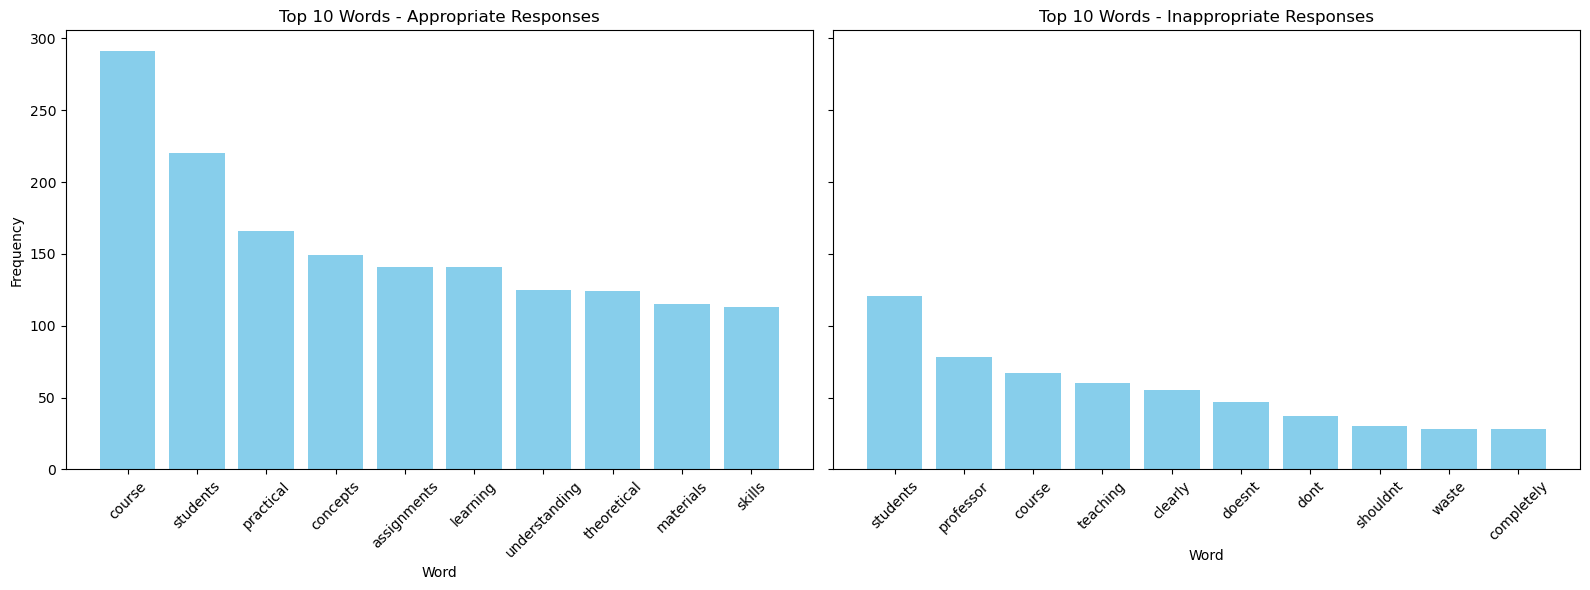

In [5]:
import matplotlib.pyplot as plt
import re
from collections import Counter

# Separate responses
appropriate_responses = survey_df.loc[survey_df["inappropriate_appropriate"] == "appropriate", "student_response_clean"]
non_appropriate_responses = survey_df.loc[survey_df["inappropriate_appropriate"] == "inappropriate", "student_response_clean"]

def get_top_words(text_series, n=10):
    big_text = " ".join(text_series).lower()
    words = re.findall(r'\b\w+\b', big_text)
    word_counts = Counter(words)
    return word_counts.most_common(n)

# Get top words for each
top_10_appropriate = get_top_words(appropriate_responses, 10)
top_10_non_appropriate = get_top_words(non_appropriate_responses, 10)

words_appropriate, counts_appropriate = zip(*top_10_appropriate)
words_non_appropriate, counts_non_appropriate = zip(*top_10_non_appropriate)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot for appropriate
axes[0].bar(words_appropriate, counts_appropriate, color="skyblue")
axes[0].set_title("Top 10 Words - Appropriate Responses")
axes[0].set_xlabel("Word")
axes[0].set_ylabel("Frequency")
axes[0].tick_params(axis="x", rotation=45)

# Plot for inappropriate
axes[1].bar(words_non_appropriate, counts_non_appropriate, color="skyblue")
axes[1].set_title("Top 10 Words - Inappropriate Responses")
axes[1].set_xlabel("Word")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### Most Common Words: Categorisation

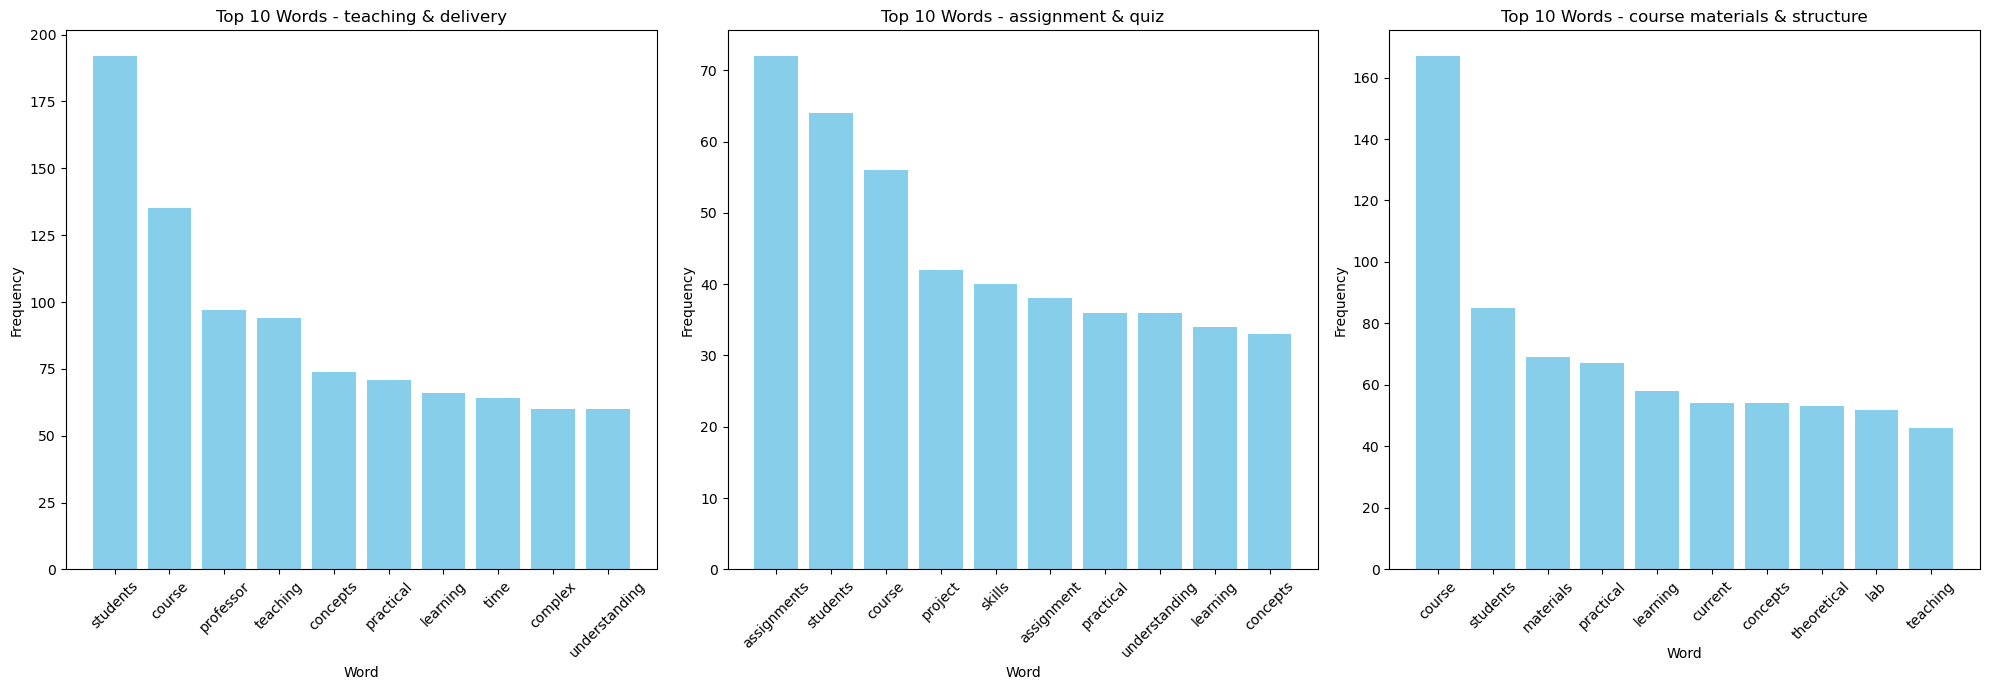

In [6]:
import matplotlib.pyplot as plt
import re
from collections import Counter

# Get unique categories
categories = survey_df['category'].dropna().unique()

n_cols = 3
fig, axes = plt.subplots(1, n_cols, figsize=(20, 7))
axes = axes.flatten()

# Count top words per category
for i, category in enumerate(categories):
    responses = survey_df.loc[survey_df["category"] == category, "student_response_clean"]
    top_words = get_top_words(responses, 10)

    if top_words:
        words, counts = zip(*top_words)
        axes[i].bar(words, counts, color="skyblue")
        axes[i].set_title(f"Top 10 Words - {category}")
        axes[i].set_xlabel("Word")
        axes[i].set_ylabel("Frequency")
        axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Label Quality Diagnostic

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

### Helper to convert multi-label lists to unique combination strings
def multi_label_to_combination(y_multi):
    y_uniform = [
        labels if isinstance(labels, (list, np.ndarray)) else [labels]
        for labels in y_multi
    ]
    return np.array([", ".join(map(str, labels)) for labels in y_uniform])

### Text Embeddings
def create_text_embeddings_sentence_transformer(texts, model_name='all-MiniLM-L6-v2'):
    model = SentenceTransformer(model_name)
    embeddings = model.encode(texts, show_progress_bar=True)
    return embeddings

### UMAP + t-SNE Visualization Function
def visualize_embeddings_side_by_side(X, y, filter_labels=None):
    y_comb = multi_label_to_combination(y)
    unique_labels = np.unique(y_comb)
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Compute embeddings
    reducer_umap = umap.UMAP(n_components=2, random_state=42, n_neighbors= 10, n_jobs=-1)
    embedding_umap = reducer_umap.fit_transform(X_scaled)
    
    X_pca = PCA(n_components=50).fit_transform(X_scaled)
    embedding_tsne = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(X_pca)
    
    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    # UMAP
    for i, label in enumerate(unique_labels):
        if filter_labels is not None and label in filter_labels:
            continue  # Skip plotting this label
        mask = y_comb == label
        axes[0].scatter(embedding_umap[mask, 0], embedding_umap[mask, 1],
                        c=[colors[i]], label=label, alpha=0.8, s=50)
    axes[0].set_title("UMAP")
    axes[0].set_xlabel("Component 1")
    axes[0].set_ylabel("Component 2")
    
    # t-SNE
    for i, label in enumerate(unique_labels):
        if filter_labels is not None and label in filter_labels:
            continue 
        mask = y_comb == label
        axes[1].scatter(embedding_tsne[mask, 0], embedding_tsne[mask, 1],
                        c=[colors[i]], label=label, alpha=0.8, s=50)
    axes[1].set_title("t-SNE")
    axes[1].set_xlabel("Component 1")
    axes[1].set_ylabel("Component 2")
    
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    return embedding_umap, embedding_tsne

### Generate Visualisation
def analyze_text_classification_overlap(df, text_column='text', 
                                        label_column='label', y_pred=None, filter_labels=None):
    texts = df[text_column].values
    y_true = df[label_column].values  # Can be single-label or multi-label
    
    # Create embeddings
    X = create_text_embeddings_sentence_transformer(texts)
    
    # Side-by-side visualization
    embedding_umap, embedding_tsne = visualize_embeddings_side_by_side(
        X, y_true, filter_labels
    )

    results = {
        'embeddings': X,
        'umap_embedding': embedding_umap,
        'tsne_embedding': embedding_tsne
    }
    return results


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


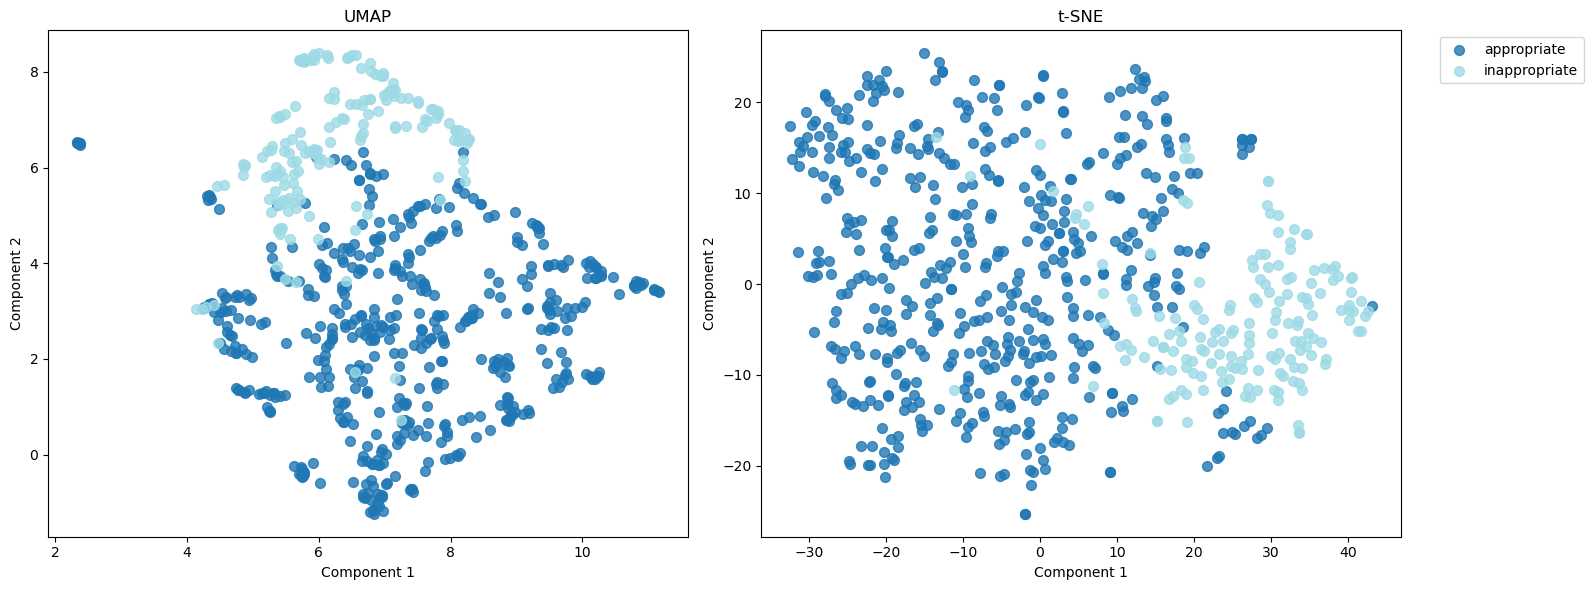

In [8]:
results_binary = analyze_text_classification_overlap(survey_df, text_column='student_response', label_column='inappropriate_appropriate')

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


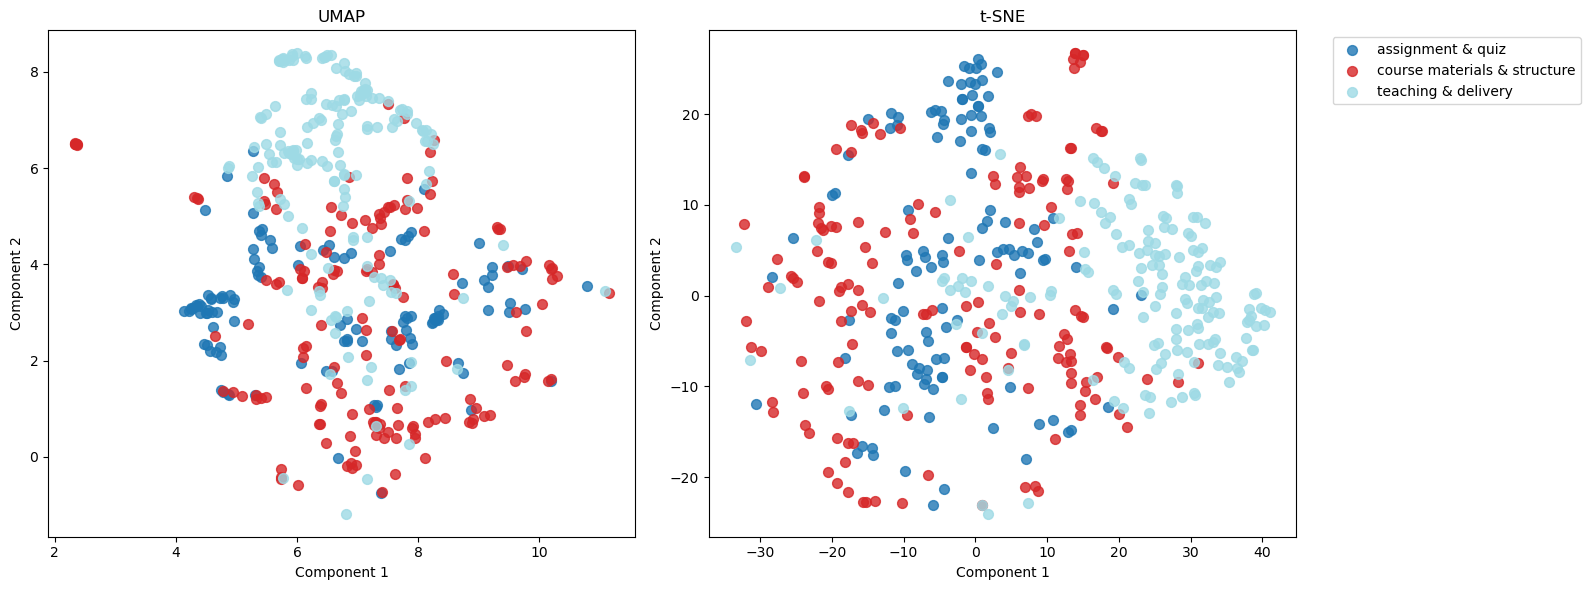

In [9]:
results_categorisation_without_mixed = analyze_text_classification_overlap(survey_df, text_column='student_response', label_column='category_mixed', filter_labels='mixed')

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


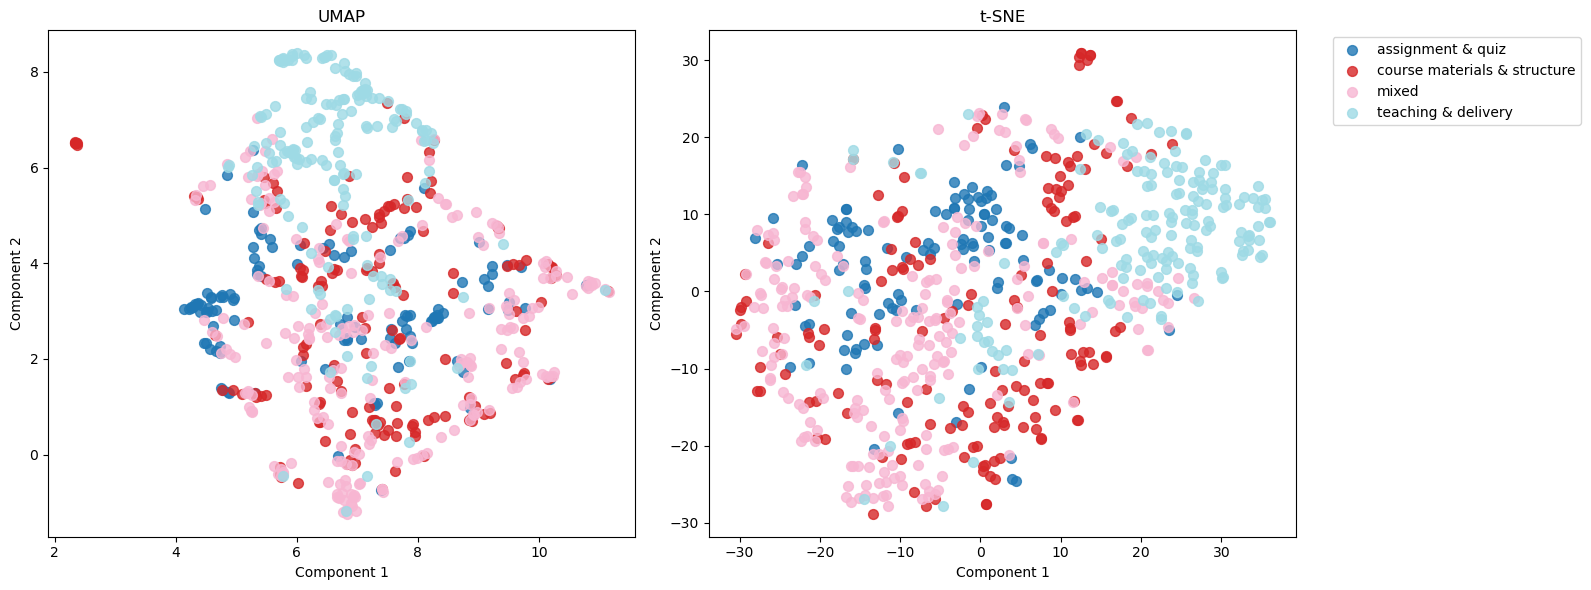

In [10]:
results_categorisation = analyze_text_classification_overlap(survey_df, text_column='student_response', label_column='category_mixed')